In [22]:
import pandas as pd
import numpy as np
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statistics


In [23]:
df = pd.read_csv('data/Cleaned_dataset.csv')

target = "Fare"

categorical_cols = [
    "Journey_day", "Airline", "Class", "Source", "Departure", "Total_stops", "Arrival", "Destination"
]

numeric_cols = [
    "Duration_in_hours", "Days_left"
]

df = df[categorical_cols + numeric_cols + [target]].dropna()

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [24]:
X = df.drop(columns=[target])
y = df[target].values.astype("float32")

# Log-transform fares, as prices are skewed
y_log = np.log1p(y).astype("float32")

y_mean = y_log.mean()
y_std = y_log.std()

y_scaled = ((y_log - y_mean) / y_std).astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_scaled, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype("float32")
X_test = scaler.transform(X_test).astype("float32")

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test)

In [25]:
pyro.clear_param_store()

x_features = X_train_t.shape[1]

def model(X, y=None):
    n_obs, n_features = X.shape

    alpha = pyro.sample("alpha", dist.Normal(0., 5.))
    beta = pyro.sample(
        "beta", dist.Normal(torch.zeros(n_features), torch.ones(n_features)).to_event(1)
    )
    sigma = pyro.sample("sigma", dist.HalfNormal(1.))

    mu  = alpha + X @ beta

    with pyro.plate("data", n_obs):
        pyro.sample("obs", dist.Normal(mu, sigma), obs=y)

def guide (X, y=None):
    n_features = X.shape[1]

    alpha_loc = pyro.param("alpha_loc", torch.tensor(0.))
    alpha_scale = pyro.param(
        "alpha_scale", torch.tensor(1.), constraint=dist.constraints.positive
    )

    beta_loc = pyro.param("beta_loc", torch.zeros(n_features))
    beta_scale = pyro.param(
        "beta_scale", torch.ones(n_features), constraint=dist.constraints.positive
    )

    sigma_scale = pyro.param(
        "sigma_scale", torch.tensor(1.), constraint=dist.constraints.positive
    )

    pyro.sample("alpha", dist.Normal(alpha_loc, alpha_scale))
    pyro.sample("beta", dist.Normal(beta_loc, beta_scale).to_event(1))
    pyro.sample("sigma", dist.HalfNormal(sigma_scale))

In [26]:
optimizer = Adam({"lr": 0.003})
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

num_steps = 3000
losses = []

for step in range(num_steps):
    loss = svi.step(X_train_t, y_train_t)
    losses.append(loss)

    if step % 500 == 0:
        print(f"Step {step} | Loss: {loss:.2f}")


Step 0 | Loss: 6376906.49
Step 500 | Loss: 40793346.47
Step 1000 | Loss: 15039725.22
Step 1500 | Loss: 2274726.06
Step 2000 | Loss: 1073882.82
Step 2500 | Loss: 17060663.69


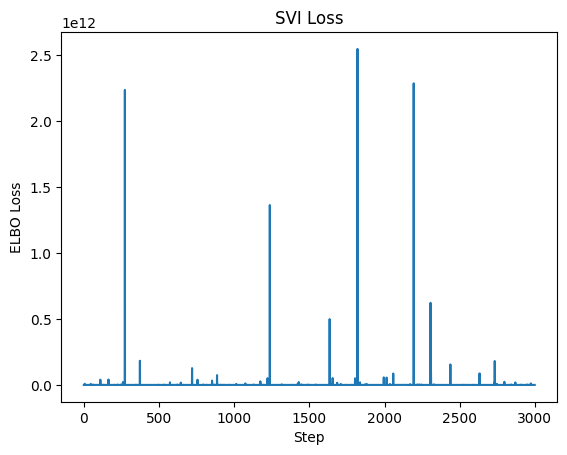

In [27]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("SVI Loss")
plt.xlabel("Step")
plt.ylabel("ELBO Loss")
plt.show()

In [28]:
# Posterior prediction

predictive = Predictive(
    model,
    guide = guide,
    num_samples=1000,
    return_sites=("obs", "alpha", "beta", "sigma")
)

posterior_samples = predictive(X_test_t, None)

y_pred_scaled_samples = posterior_samples["obs"].detach().numpy()

y_pred_log_samples = y_pred_scaled_samples * y_std + y_mean
y_pred_log_mean = y_pred_log_samples.mean(axis=0)

# Convert back from log-fare to fare
y_pred = np.expm1(y_pred_log_mean)

y_test_original = np.expm1(y_test * y_std + y_mean)

In [29]:
mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 12515.8779296875
RMSE: 19542.631961944124


In [30]:
# Predict Uncertainty

lower = np.expm1(np.percentile(y_pred_log_samples, 2.5, axis=0))
upper = np.expm1(np.percentile(y_pred_log_samples, 97.5, axis=0))

results = pd.DataFrame({
    "actual_fare": y_test_original,
    "predicted_fare": y_pred,
    "lower_95": lower,
    "upper_95": upper
})

In [31]:
beta_mean = pyro.param("beta_loc").detach().numpy()

coef_df = pd.DataFrame({
    "feature": X.columns,
    "posterior_mean_beta": beta_mean
}).sort_values("posterior_mean_beta", ascending=False)

coef_df.head(20)

,feature,posterior_mean_beta
31,Arrival_After 6 PM,0.223254
25,Departure_6 AM - 12 PM,0.208139
34,Destination_Chennai,0.201528
15,Airline_Vistara,0.141040
24,Source_Mumbai,0.111912
37,Destination_Kolkata,0.090025
35,Destination_Delhi,0.084674
2,Journey_day_Monday,0.070713
19,Source_Bangalore,0.067229
22,Source_Hyderabad,0.063597


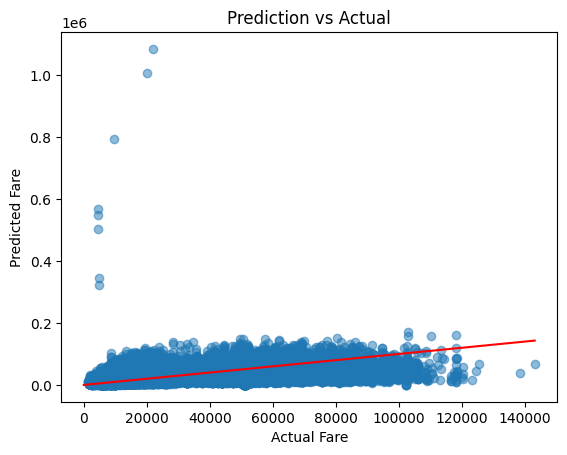

In [32]:
plt.scatter(results["actual_fare"], results["predicted_fare"], alpha=0.5)
plt.plot([0, results["actual_fare"].max()],
         [0, results["actual_fare"].max()],
         color="red")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Prediction vs Actual")
plt.show()